Представленный здесь набор данных для A/B-тестирования — это самостоятельно сгенерированный синтетический набор данных, созданный с использованием методов случайной выборки, предоставляемых пакетом Numpy. Набор данных имитирует информацию о посещениях пользователями вымышленного розничного веб-сайта в Великобритании. Пользователи разделены на две группы, A и B, каждая из которых представляет собой контрольную и экспериментальную группы соответственно. Представьте, что розничной компании необходимо протестировать новое изменение на веб-сайте: « Проводят ли люди время на веб-сайте, если цвет фона веб-сайта белый или черный ?» Этот вопрос задается для достижения конечной цели анализа — повышения вовлеченности пользователей, будь то покупка, регистрация и т. д.

Итак, в этом сценарии пусть группе А будет присвоен цвет «белый», который является настройкой фона по умолчанию на веб-сайте и представляет собой контрольную группу. Также пусть группе B будет присвоен цвет «черный», что соответствует более новой настройке для тестирования. Главная цель — понять, происходит ли существенное улучшение количества просмотров веб-сайта при применении более новой настройки. Это можно сделать с помощью A/B-тестирования.

Этот набор данных предназначен для отработки навыков A/B-тестирования, поскольку это очень важная тема для будущих аналитиков данных. Описание столбцов приведено ниже:

Идентификатор пользователя : служит идентификатором для каждого пользователя.

Группа : включает в себя как контрольную группу (A), так и группу лечения (B).

Просмотры страниц : Количество страниц, просмотренных пользователем за сессию.

Затраченное время : общее количество времени в секундах, которое пользователь провел на сайте за сессию.

Конверсия : указывает, выполнил ли пользователь желаемое действие (Да/Нет).

Устройство : Тип устройства, используемого для доступа к веб-сайту.

Местоположение : Страна в Великобритании, где находится пользователь.

Данный набор данных также может быть использован для получения сегментированных аналитических данных посредством соответствующей визуализации данных в зависимости от типа устройства и местоположения.

In [1]:
import pandas as pd 
import numpy as np 
from matplotlib import pyplot as plt
import plotly.graph_objects as go
import seaborn as sns
import plotly.express as px
from scipy.stats import chi2_contingency, ttest_ind


In [2]:
df = pd.read_csv("data\\ab_testing.csv")
df.head(5)

,User ID,Group,Page Views,Time Spent,Conversion,Device,Location
0,14292,B,3,424,No,Mobile,Northern Ireland
1,11682,A,9,342,No,Mobile,Scotland
2,19825,A,2,396,No,Desktop,Northern Ireland
3,16080,B,4,318,No,Desktop,Wales
4,18851,A,1,338,Yes,Desktop,Scotland


In [3]:
df.dtypes

User ID        int64
Group         object
Page Views     int64
Time Spent     int64
Conversion    object
Device        object
Location      object
dtype: object

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   User ID     5000 non-null   int64 
 1   Group       5000 non-null   object
 2   Page Views  5000 non-null   int64 
 3   Time Spent  5000 non-null   int64 
 4   Conversion  5000 non-null   object
 5   Device      5000 non-null   object
 6   Location    5000 non-null   object
dtypes: int64(3), object(4)
memory usage: 273.6+ KB


In [5]:
df.shape

(5000, 7)

#### conversion rate

In [6]:
df.groupby('Group')['Group'].count()

Group
A    2519
B    2481
Name: Group, dtype: int64

In [7]:
df.groupby('Conversion')['Conversion'].count()

Conversion
No     4515
Yes     485
Name: Conversion, dtype: int64

In [8]:
df_a = df[df['Group'] == "A"]
df_b = df[df['Group'] == "B"]

In [20]:
group_a = df_a.groupby('Conversion')['Conversion']
group_a.count()

Conversion
No     2383
Yes     136
Name: Conversion, dtype: int64

In [24]:
group_b = df_b.groupby('Conversion')['Conversion']
group_b.count()

Conversion
No     2132
Yes     349
Name: Conversion, dtype: int64

In [30]:
print(f"Процент конверсии в группе A:\n{group_a.count()['Yes']/group_a.count().sum()*100:.2f}% ")

Процент конверсии в группе A:
5.40% 


In [31]:
print(f"Процент конверсии в группе B:\n{group_b.count()['Yes']/group_b.count().sum()*100:.2f}% ")

Процент конверсии в группе B:
14.07% 


Text(0, 0.5, 'Количество конверсий')

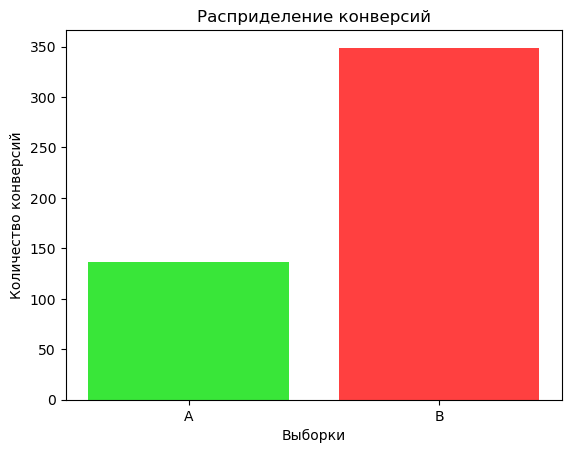

In [11]:
categories = ["A" ,"B"]
values = [df_a.groupby('Conversion')['Conversion'].count()["Yes"] , df_b.groupby('Conversion')['Conversion'].count()['Yes']]
plt.bar(categories, values, color=["#39E639","#FF4040"])#[green , red]
plt.title("Расприделение конверсий")
plt.xlabel("Выборки")
plt.ylabel("Количество конверсий")

#### Device &  Location

In [12]:
positive_conversion = df[df['Conversion']=='Yes'].reset_index(drop=True)

In [13]:
grouped_counts = positive_conversion.groupby(['Group' , 'Device' , 'Location'])['Conversion'].count().reset_index(name = 'Count')

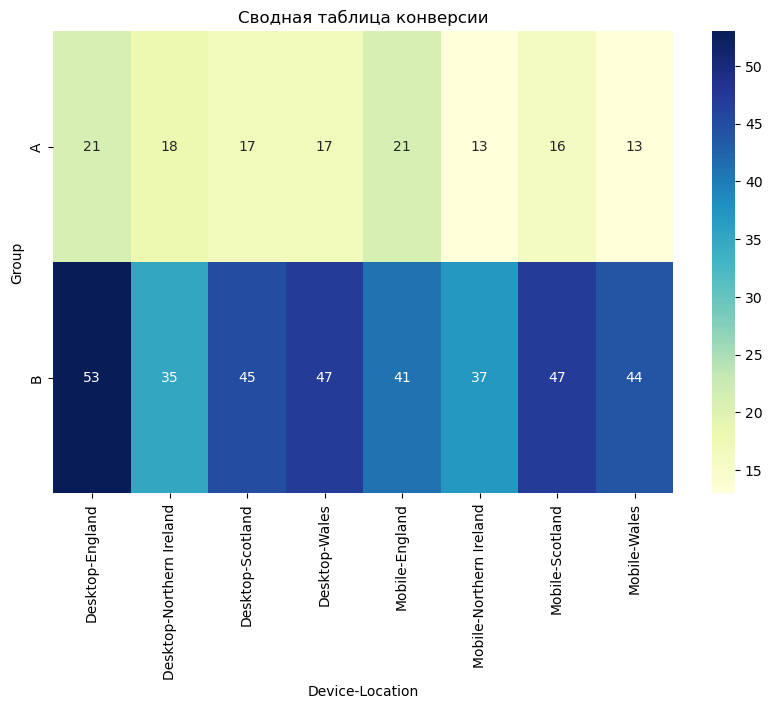

In [14]:
pivot_table = grouped_counts.pivot_table(index = 'Group' , columns=['Device' , 'Location'] , values = "Count")
plt.figure(figsize=(10, 6))
sns.heatmap(pivot_table, annot=True, cmap="YlGnBu")
plt.title("Сводная таблица конверсии")
plt.show()

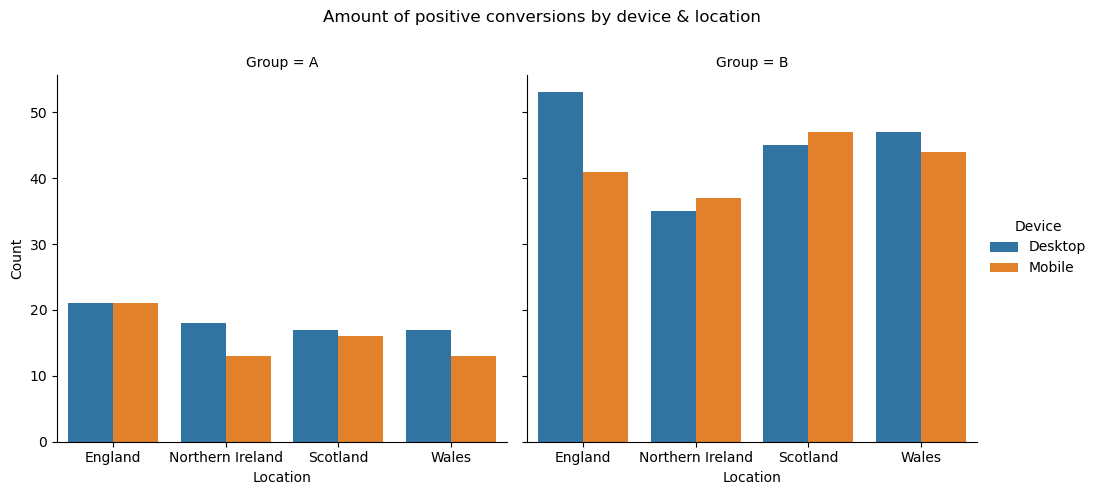

In [15]:
graph = sns.catplot(data = grouped_counts , x = 'Location' , y = 'Count' , hue = 'Device' , kind = 'bar' , col = 'Group')
graph.fig.suptitle("Amount of positive conversions by device & location")
graph.fig.subplots_adjust(top=0.85)
plt.show()

#### P-value , chi-square

In [16]:
contingency = pd.crosstab(df['Group'], df['Conversion'])
chi2, p, dof, expected = chi2_contingency(contingency)
print(f'Chi-square: {chi2}, p_value: {p}')

Chi-square: 106.22812337440538, p_value: 6.571736018334222e-25


$H_0 - ~коневерсия ~в ~группах ~A ~и ~B ~одинковая\newline H_1 - ~коневерсия ~в ~группах ~A ~и ~B ~различна\newline\alpha = 0.05\newline p\_value < \alpha$

In [17]:
# Check the time spent difference between groups
# T-statistic shows average difference of time spent between Two groups
group_a = df[df['Group'] == 'A']['Time Spent']
group_b = df[df['Group'] == 'B']['Time Spent']

t_stat, p = ttest_ind(group_a, group_b)
print(f"T-statistic: {t_stat}, p-value: {p}")

T-statistic: -0.46954858146462514, p-value: 0.6386980515632602


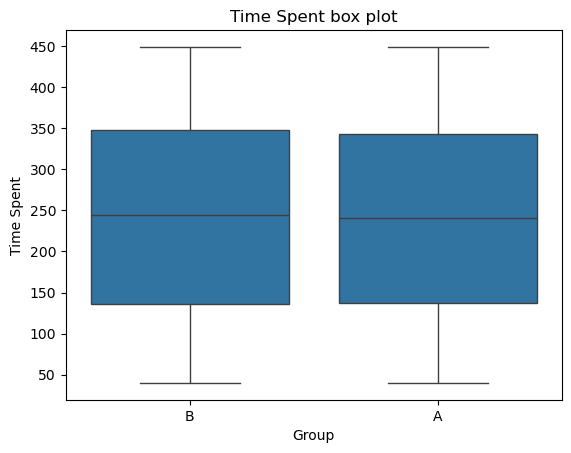

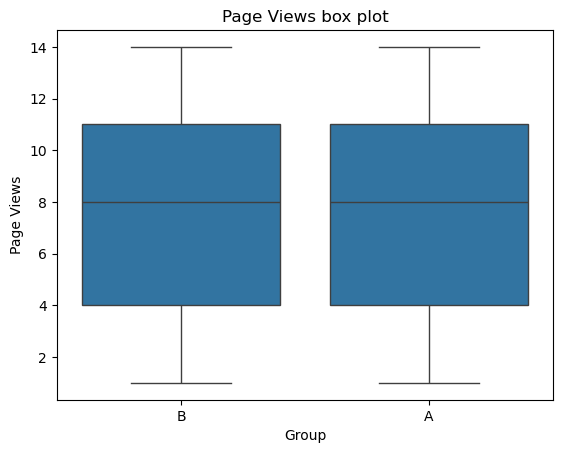

In [18]:
sns.boxplot(data=df, x='Group', y='Time Spent')
plt.title('Time Spent box plot')
plt.xlabel('Group')
plt.ylabel('Time Spent')
plt.show()

sns.boxplot(data=df, x='Group', y='Page Views')
plt.title('Page Views box plot')
plt.xlabel('Group')
plt.ylabel('Page Views')
plt.show()

Значения t критерия близкого к нгулю говорит , о отсутсвии существенной разницы $\newline$
p_value > 0.05 , при том значительно , позволяет нам заключить , что результат статистически не значим .

#### Заключения

Группа B (чёрный фон) показала статистически значимо более высокую конверсию (14.1% против 5.4%, p < 0.001). При этом время на сайте не различается (p = 0.64), что говорит о более эффективном вовлечении пользователе